In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

np.random.seed(123)

# Simulated data: AI assistant feature rollout (phased, not random)
n = 600
plan_tier = np.random.choice([0, 1, 2], n, p=[0.5, 0.35, 0.15])
tenure_days = np.random.randint(0, 366, n)
prior_sessions = np.random.poisson(12, n) + np.random.randint(0, 20, n)
platform = np.random.choice([0, 1], n, p=[0.6, 0.4])
signup_cohort = np.random.choice([0, 1, 2], n, p=[0.4, 0.35, 0.25])

# Treatment: higher tier, tenure, prior sessions, mobile → more likely to get feature
logit_p = -2.0 + 0.5*plan_tier + 0.003*tenure_days + 0.02*prior_sessions + 0.4*platform + 0.2*signup_cohort
ps_true = 1 / (1 + np.exp(-np.clip(logit_p, -10, 10)))
D = (np.random.uniform(0, 1, n) < ps_true).astype(int)

# Outcome: weekly_active_minutes. True effect of feature = +15 min
Y = 80 + 15*D + 8*plan_tier + 0.05*tenure_days + 0.8*prior_sessions + 5*platform + 3*signup_cohort + np.random.normal(0, 12, n)
Y = np.maximum(Y, 0)

df = pd.DataFrame({
    'plan_tier': plan_tier, 'tenure_days': tenure_days, 'prior_sessions': prior_sessions,
    'platform': platform, 'signup_cohort': signup_cohort, 'D': D, 'weekly_active_minutes': Y
})

print("Dataset: AI assistant feature rollout")
print(f"  n = {len(df)}, Treated: {D.sum()}, Control: {n - D.sum()}")
print(f"  True causal effect: +15 min/week")
print(df.head(10))

Dataset: AI assistant feature rollout
  n = 600, Treated: 254, Control: 346
  True causal effect: +15 min/week
   plan_tier  tenure_days  prior_sessions  platform  signup_cohort  D  \
0          1          231              16         1              2  0   
1          0          276              28         0              2  0   
2          0          345              21         0              1  1   
3          1          353              23         0              1  1   
4          1           39              15         0              0  0   
5          0          205              28         0              0  0   
6          2          298              17         0              0  0   
7          1           58              31         0              0  1   
8          0           48              14         1              2  0   
9          0          174               9         0              2  0   

   weekly_active_minutes  
0             132.725826  
1             114.294894  
2   

In [11]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns

# 1. Fit logistic regression: D ~ covariates
covariates = ['plan_tier', 'tenure_days', 'prior_sessions', 'platform', 'signup_cohort']
formula = 'D ~ ' + ' + '.join(covariates)

logit_mod = smf.logit(formula=formula, data=df)
logit_res = logit_mod.fit()
print(logit_res.summary())
print('Plan Tier has the largest positive with a coefficient of .5289 and satistical significance due to a p value of 0')

Optimization terminated successfully.
         Current function value: 0.651636
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                      D   No. Observations:                  600
Model:                          Logit   Df Residuals:                      594
Method:                           MLE   Df Model:                            5
Date:                Thu, 26 Mar 2026   Pseudo R-squ.:                 0.04360
Time:                        23:37:04   Log-Likelihood:                -390.98
converged:                       True   LL-Null:                       -408.81
Covariance Type:            nonrobust   LLR p-value:                 1.115e-06
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -1.2951      0.371     -3.490      0.000      -2.022      -0.568
plan_tier        

In [12]:
# 2. Add df['ps'] = fitted propensity scores
df['ps'] = logit_res.predict(df[covariates])
display(df[['D', 'ps'] + covariates].head())

,D,ps,plan_tier,tenure_days,prior_sessions,platform,signup_cohort
0,0,0.623247,1,231,16,1,2
1,0,0.396232,0,276,28,0,2
2,1,0.391481,0,345,21,0,1
3,1,0.523872,1,353,23,0,1
4,0,0.319956,1,39,15,0,0


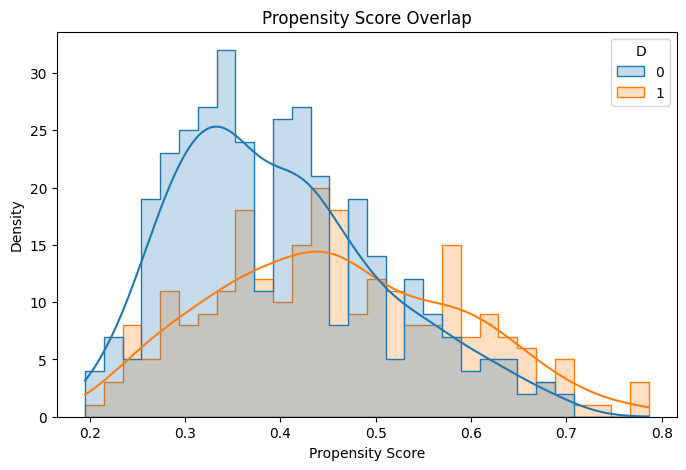

Overlap is sufficient


In [13]:
# 3. Plot overlap (KDE or histogram)
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='ps', hue='D', bins=30, kde=True, element='step', common_norm=False)
plt.title('Propensity Score Overlap')
plt.xlabel('Propensity Score')
plt.ylabel('Density')
plt.show()
print('Overlap is sufficient')

In [14]:
# 4. Compute ATE via IPW (clip ps to avoid extreme weights)
ps_clipped = np.clip(df['ps'], 0.05, 0.95)
df['weight'] = np.where(df['D'] == 1, 1 / ps_clipped, 1 / (1 - ps_clipped))

ate_ipw = np.average(df[df['D'] == 1]['weekly_active_minutes'], weights=df[df['D'] == 1]['weight']) - \
          np.average(df[df['D'] == 0]['weekly_active_minutes'], weights=df[df['D'] == 0]['weight'])

print(f"IPW ATE: {ate_ipw:.2f}")

IPW ATE: 15.33


In [15]:
# 5. Compare naive ATE, IPW ATE, true effect (15)
naive_ate = df[df['D'] == 1]['weekly_active_minutes'].mean() - df[df['D'] == 0]['weekly_active_minutes'].mean()
true_effect = 15.0

print("--- Comparison ---")
print(f"Naive ATE:  {naive_ate:.2f}")
print(f"IPW ATE:    {ate_ipw:.2f}")
print(f"True Effect: {true_effect:.2f}")

--- Comparison ---
Naive ATE:  18.80
IPW ATE:    15.33
True Effect: 15.00
